# End-to-End NLP Project

# Model Experimentation

## Project

Email Spam Detection using Machine Learning

## Objective

This notebook evaluates multiple feature extraction techniques and machine learning algorithms for spam classification.

Different vectorization methods and classifiers will be compared using the same evaluation metrics to identify the best-performing pipeline.

## Author

Aneesh Jose

# Problem Statement

Machine learning algorithms cannot process raw text directly.

The cleaned SMS messages generated during preprocessing must first be converted into numerical feature vectors.

This notebook compares:

- Bag of Words
- TF-IDF

using multiple machine learning algorithms to determine the best-performing spam classification model.

In [45]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [16]:
df = pd.read_csv(
    "../artifacts/data_transformation/spam_cleaned.csv",
    keep_default_na=False
)
df.head()

,label,message,transformed_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## Load Processed Dataset

The cleaned dataset generated during the preprocessing stage is loaded.

This dataset contains both the original SMS messages and the cleaned text that will be used for vectorization.

In [17]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["label"])

df.head()

,label,message,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   label             5572 non-null   int64
 1   message           5572 non-null   str  
 2   transformed_text  5572 non-null   str  
dtypes: int64(1), str(2)
memory usage: 822.7 KB


In [19]:
df.loc[df["transformed_text"].isnull(), "message"]

Series([], Name: message, dtype: str)

## Encode Target Variable

Machine learning models require numerical target values.

The label column is encoded as:

- Ham → 0
- Spam → 1

In [20]:
X = df["transformed_text"]

y = df["label"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train-Test Split

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

The `stratify` parameter preserves the original class distribution in both sets, ensuring that spam and ham messages remain proportionally represented.

# Bag of Words (BoW)

## Objective

Machine learning algorithms cannot understand text directly.

Therefore, the cleaned SMS messages must first be converted into numerical feature vectors.

The Bag of Words (BoW) model is one of the simplest and most widely used text vectorization techniques.

It converts each document into a vector representing the frequency of words present in the document.

In this section, we will:

- Build a vocabulary
- Convert text into numerical vectors
- Train multiple machine learning models
- Evaluate their performance

In [22]:
vectorizer = CountVectorizer()

In [23]:
X_train.info()

<class 'pandas.Series'>
Index: 4457 entries, 184 to 762
Series name: transformed_text
Non-Null Count  Dtype
--------------  -----
4457 non-null   str  
dtypes: str(1)
memory usage: 271.4 KB


In [24]:
X_train_bow = vectorizer.fit_transform(X_train)

### Learn the Vocabulary

The `fit_transform()` method performs two operations:

1. **fit()**

Learns every unique word from the training dataset.

2. **transform()**

Converts every SMS message into a numerical feature vector using the learned vocabulary.

The resulting matrix is called a **Document-Term Matrix (DTM)**.

## How does Bag of Words work?

The Bag of Words model creates a vocabulary containing every unique word in the dataset.

Each document is then represented as a numerical vector where each value corresponds to the frequency of a word in that document.

Although Bag of Words ignores grammar and word order, it often performs surprisingly well for text classification problems such as spam detection.

In [25]:
X_test_bow = vectorizer.transform(X_test)

In [26]:
X_train_bow.shape

(4457, 5979)

### Understanding the Shape

The document-term matrix has:

- One row for each SMS message.
- One column for each unique word learned from the training data.

Every value represents the frequency of a word in a particular message.

In [27]:
len(vectorizer.vocabulary_)

5979

In [28]:
list(vectorizer.vocabulary_.items())[:20]

[('guy', 2577),
 ('close', 1472),
 ('pleas', 4074),
 ('come', 1509),
 ('imin', 2842),
 ('urgoin', 5559),
 ('outl8r', 3905),
 ('reallyne', 4355),
 ('dontpleas', 1886),
 ('dontignor', 1885),
 ('mycal', 3634),
 ('thecd', 5263),
 ('tome', 5358),
 ('2moro', 313),
 ('ok', 3836),
 ('sri', 4975),
 ('knw', 3108),
 ('siva', 4789),
 ('tat', 5187),
 ('askd', 867)]

In [29]:
X_train_bow[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 5979))

### Sparse Matrix Representation

The Bag of Words representation is stored as a sparse matrix because most documents contain only a small subset of the vocabulary.

Using a sparse matrix significantly reduces memory usage compared to storing a dense matrix.

In [36]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a machine learning model.

    Parameters
    ----------
    model : Machine Learning Estimator
        The model to be trained.

    X_train : array-like
        Training feature matrix.

    X_test : array-like
        Testing feature matrix.

    y_train : array-like
        Training labels.

    y_test : array-like
        Testing labels.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print Results
    print("=" * 60)
    print(f"Model : {model.__class__.__name__}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    # Return metrics
    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [41]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [42]:
results = []

for model_name, model in models.items():

    metrics = evaluate_model(
        model,
        X_train_bow,
        X_test_bow,
        y_train,
        y_test
    )

    results.append(metrics)

Model : MultinomialNB
Accuracy : 0.9794
Precision: 0.9632
Recall   : 0.8792
F1 Score : 0.9193

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.96      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix
[[961   5]
 [ 18 131]]
Model : LogisticRegression
Accuracy : 0.9821
Precision: 0.9850
Recall   : 0.8792
F1 Score : 0.9291

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix
[[964   2]
 [ 18 131]]
Model : LinearSVC
Accuracy 

In [43]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,MultinomialNB,0.979372,0.963235,0.879195,0.919298
1,LogisticRegression,0.982063,0.984962,0.879195,0.929078
2,LinearSVC,0.982063,0.984962,0.879195,0.929078
3,RandomForestClassifier,0.971300,1.000000,0.785235,0.879699


In [44]:
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.982063,0.984962,0.879195,0.929078
1,LinearSVC,0.982063,0.984962,0.879195,0.929078
2,MultinomialNB,0.979372,0.963235,0.879195,0.919298
3,RandomForestClassifier,0.971300,1.000000,0.785235,0.879699


## Model Comparison

The models are ranked based on their F1-score.

The F1-score is particularly useful for imbalanced datasets because it balances both Precision and Recall.

A higher F1-score indicates a better balance between correctly identifying spam messages and minimizing false positives.

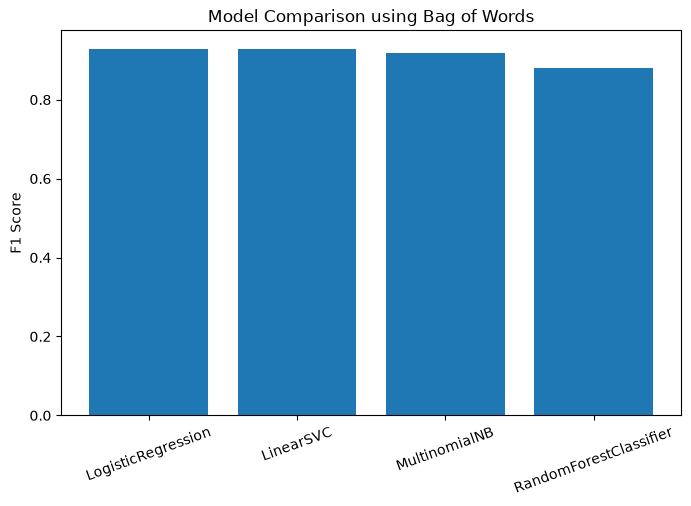

In [46]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.xticks(rotation=20)

plt.ylabel("F1 Score")

plt.title("Model Comparison using Bag of Words")

plt.show()

## Evaluation Metrics

The following metrics are used to evaluate the classifier:

- **Accuracy**: Overall percentage of correct predictions.
- **Precision**: Of all messages predicted as spam, how many were actually spam?
- **Recall**: Of all actual spam messages, how many were correctly identified?
- **F1-score**: Harmonic mean of Precision and Recall.

For spam detection, Precision and Recall are generally more informative than Accuracy because the dataset is imbalanced.

# 8. TF-IDF (Term Frequency–Inverse Document Frequency)

## Objective

Bag of Words treats every word equally by counting how often it appears in a document.

However, common words that appear in many documents may not be useful for distinguishing spam from ham.

TF-IDF improves upon Bag of Words by assigning higher importance to informative words while reducing the importance of frequently occurring words.

In this section, we will:

- Convert the cleaned text into TF-IDF feature vectors.
- Train the same machine learning models.
- Compare their performance with Bag of Words.

In [47]:
tfidf = TfidfVectorizer()

In [48]:
X_train_tfidf = tfidf.fit_transform(X_train)

### Learn TF-IDF Representation

The `fit_transform()` method performs two operations:

- Learns the vocabulary from the training data.
- Converts each SMS message into a TF-IDF feature vector.

Unlike Bag of Words, the feature values are weighted rather than simple word counts.

In [49]:
X_test_tfidf = tfidf.transform(X_test)

In [50]:
X_train_tfidf.shape

(4457, 5979)

In [51]:
len(tfidf.vocabulary_)

5979

In [52]:
list(tfidf.vocabulary_.items())[:20]

[('guy', 2577),
 ('close', 1472),
 ('pleas', 4074),
 ('come', 1509),
 ('imin', 2842),
 ('urgoin', 5559),
 ('outl8r', 3905),
 ('reallyne', 4355),
 ('dontpleas', 1886),
 ('dontignor', 1885),
 ('mycal', 3634),
 ('thecd', 5263),
 ('tome', 5358),
 ('2moro', 313),
 ('ok', 3836),
 ('sri', 4975),
 ('knw', 3108),
 ('siva', 4789),
 ('tat', 5187),
 ('askd', 867)]

In [53]:
X_train_tfidf[:5].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 5979))

### Understanding TF-IDF Values

Unlike Bag of Words, TF-IDF does not simply count how many times a word appears.

Instead, it assigns a weight to each word based on:

- How frequently the word appears in a document.
- How rare the word is across the entire dataset.

Words that are common across many documents receive lower weights, while more informative words receive higher weights.

In [54]:
tfidf_results = []

for model_name, model in models.items():

    metrics = evaluate_model(
        model,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )

    tfidf_results.append(metrics)

Model : MultinomialNB
Accuracy : 0.9614
Precision: 1.0000
Recall   : 0.7114
F1 Score : 0.8314

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115

Confusion Matrix
[[966   0]
 [ 43 106]]
Model : LogisticRegression
Accuracy : 0.9632
Precision: 1.0000
Recall   : 0.7248
F1 Score : 0.8405

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

Confusion Matrix
[[966   0]
 [ 41 108]]
Model : LinearSVC
Accuracy 

In [55]:
tfidf_results_df = pd.DataFrame(tfidf_results)

tfidf_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,MultinomialNB,0.961435,1.000000,0.711409,0.831373
1,LogisticRegression,0.963229,1.000000,0.724832,0.840467
2,LinearSVC,0.983857,0.985185,0.892617,0.936620
3,RandomForestClassifier,0.973991,1.000000,0.805369,0.892193


In [56]:
tfidf_results_df = tfidf_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

tfidf_results_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,LinearSVC,0.983857,0.985185,0.892617,0.936620
1,RandomForestClassifier,0.973991,1.000000,0.805369,0.892193
2,LogisticRegression,0.963229,1.000000,0.724832,0.840467
3,MultinomialNB,0.961435,1.000000,0.711409,0.831373


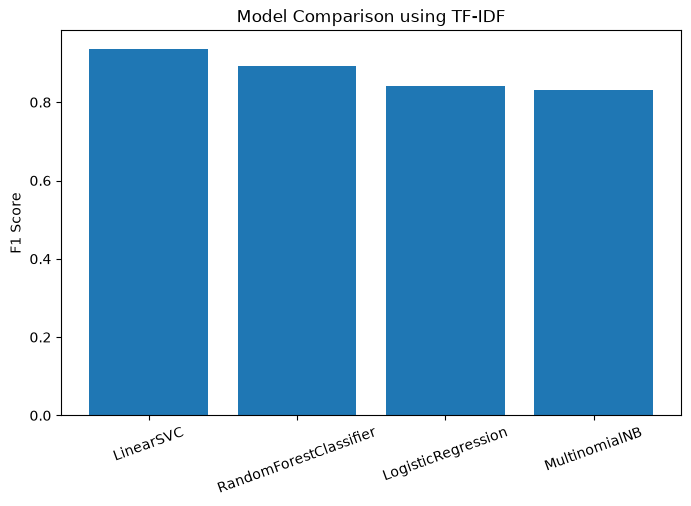

In [57]:
plt.figure(figsize=(8,5))

plt.bar(
    tfidf_results_df["Model"],
    tfidf_results_df["F1 Score"]
)

plt.xticks(rotation=20)

plt.ylabel("F1 Score")

plt.title("Model Comparison using TF-IDF")

plt.show()

In [58]:
comparison_df = pd.concat(
    [
        results_df.assign(Vectorizer="Bag of Words"),
        tfidf_results_df.assign(Vectorizer="TF-IDF")
    ],
    ignore_index=True
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Vectorizer
0,LogisticRegression,0.982063,0.984962,0.879195,0.929078,Bag of Words
1,LinearSVC,0.982063,0.984962,0.879195,0.929078,Bag of Words
2,MultinomialNB,0.979372,0.963235,0.879195,0.919298,Bag of Words
3,RandomForestClassifier,0.971300,1.000000,0.785235,0.879699,Bag of Words
4,LinearSVC,0.983857,0.985185,0.892617,0.936620,TF-IDF
5,RandomForestClassifier,0.973991,1.000000,0.805369,0.892193,TF-IDF
6,LogisticRegression,0.963229,1.000000,0.724832,0.840467,TF-IDF
7,MultinomialNB,0.961435,1.000000,0.711409,0.831373,TF-IDF


# Model Comparison

Both Bag of Words and TF-IDF were evaluated using the same train-test split and the same machine learning algorithms.

This ensures that the comparison is fair, with the only difference being the feature representation.

The best-performing combination will be selected for the final production pipeline.

In [59]:
comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,Vectorizer
4,LinearSVC,0.983857,0.985185,0.892617,0.936620,TF-IDF
0,LogisticRegression,0.982063,0.984962,0.879195,0.929078,Bag of Words
1,LinearSVC,0.982063,0.984962,0.879195,0.929078,Bag of Words
2,MultinomialNB,0.979372,0.963235,0.879195,0.919298,Bag of Words
5,RandomForestClassifier,0.973991,1.000000,0.805369,0.892193,TF-IDF
3,RandomForestClassifier,0.971300,1.000000,0.785235,0.879699,Bag of Words
6,LogisticRegression,0.963229,1.000000,0.724832,0.840467,TF-IDF
7,MultinomialNB,0.961435,1.000000,0.711409,0.831373,TF-IDF


#  Best Model Selection

After evaluating four machine learning algorithms using both Bag of Words and TF-IDF feature extraction techniques, the best-performing pipeline was:

**Vectorizer:** TF-IDF

**Classifier:** Linear Support Vector Machine (Linear SVM)

### Performance

- Accuracy: 98.39%
- Precision: 98.52%
- Recall: 89.26%
- F1 Score: 93.66%

### Why was this model selected?

- Highest F1 Score among all evaluated models.
- Excellent balance between Precision and Recall.
- Strong performance on high-dimensional sparse text features.
- Well suited for text classification tasks.

This model will be used as the final classifier in the production pipeline.

In [60]:
from pathlib import Path
import joblib

# Create models directory
model_dir = Path("../artifacts/model_trainer")
model_dir.mkdir(parents=True, exist_ok=True)

# Save the trained model
joblib.dump(models["Linear SVM"], model_dir / "spam_classifier.pkl")

# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf, model_dir / "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
